# Model Testing Notebook

Doel:
- Modellen importeren
- Trainer testen
- Model comparison uitvoeren
- Metrics bekijken
- Visualisaties maken

# WIP

- [ ] Integrate `train_model` (modern trainer) with `mode="binary"` and `mode="multiclass"`
- [ ] Test end-to-end for binary labels (capstone shadow)
- [ ] Test end-to-end for 5-class trend labels
- [ ] Add clear section: Binary vs Multiclass runs
- [ ] Final QA: no hard-coded paths, clean outputs


In [ ]:
from src.ml.training.trainer import train_model
# eventueel:
# from src.ml.training.trainer_legacy import train_model_legacy


Binary-run - Capstone

In [ ]:
result_bin = train_model(
    model,
    X_flat,
    y_binary,          # bijv. 0/1 label_1h
    mode="binary",
)


Multislass-run

In [ ]:
result_multi = train_model(
    model,
    X_flat,
    y_multiclass,      # -2..2
    mode="multiclass",
)


In [ ]:
from src.ml.evaluation.metrics import evaluate_classification_v2

metrics_bin = evaluate_classification_v2(
    y_true=result_bin.y_test,
    y_pred=result_bin.y_pred,
    mode="binary"
)


In [ ]:
metrics_multi = evaluate_classification_v2(
    y_true=result_multi.y_test,
    y_pred=result_multi.y_pred,
    mode="multiclass"
)


Imports:

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

DATA_DIR = "../data/processed"
TF = "1h"
prefix = f"btc_{TF}_featured_"


# Load NumPy arrays
X = np.load(f"{DATA_DIR}/{prefix}labels_X.npy")
y = np.load(f"{DATA_DIR}/{prefix}labels_y.npy")
t = np.load(f"{DATA_DIR}/{prefix}labels_t.npy")
label_cols = np.load(f"{DATA_DIR}/{prefix}label_cols.npy")

# Feature names from the shared repo
feature_cols = [
    "open", "high", "low", "close", "volume",
    "returns", "hl_range", "hl_pct",
    "volatility", "volatility_short",‚
    "sma_20", "sma_50", "sma_ratio",
    "rsi", "macd", "macd_signal", "macd_histogram",
    "bb_width", "bb_position",
    "volume_ratio", "price_position",
]

# Flatten 3D → 2D
X_flat = X.reshape(X.shape[0], -1)

timesteps = X.shape[1]
features = X.shape[2]

# Build column names using your colleague's feature names
flat_cols = [
    f"{feature_cols[f]}_t{timestep}"
    for timestep in range(timesteps)
    for f in range(features)
]

df = pd.DataFrame(X_flat, columns=flat_cols)
df["target_1h"] = y[:, 0]
df["target_4h"] = y[:, 1]
df["timestamp"] = pd.to_datetime(t, unit="ns")
df = df.set_index("timestamp")


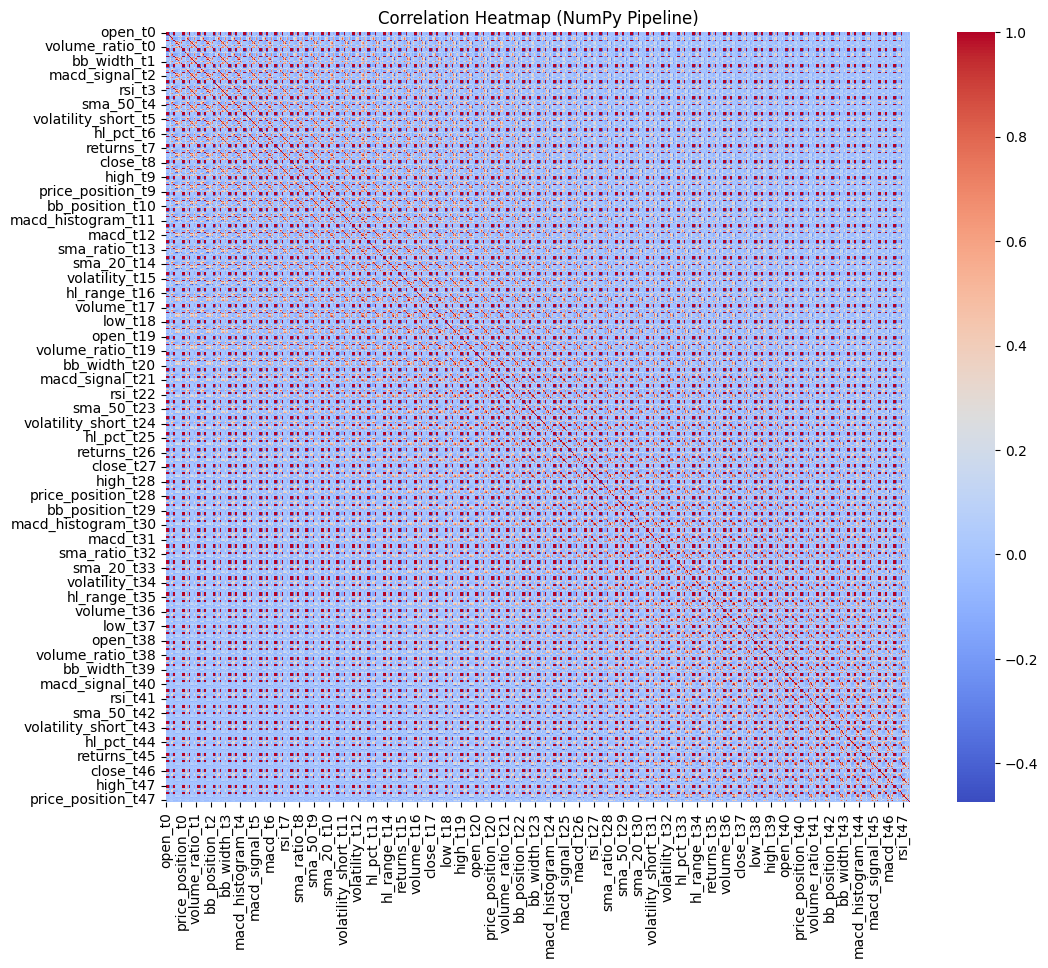

In [14]:
# Heatmap (numeric only)
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (NumPy Pipeline)")
plt.show()



In [33]:
# ============================================================
# 📘 Model Testing (NumPy Pipeline)
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

# Import models
from src.ml.models.random_forest import RandomForestModel
from src.ml.models.logistic_regression import LogisticRegressionModel
from src.ml.models.xgboost_model import XGBoostModel

# Import comparison function
from src.ml.comparison.compare import compare_models


# ============================================================
# 1. Select Target
# ============================================================

# y shape: (samples, 2) -> [label_1h, label_4h]
target = y[:, 0]   # label_1h (same as cryptopuls-AI)


# ============================================================
# 2. Define Models
# ============================================================

models = {
    "RandomForest": RandomForestModel(),
    "LogisticRegression": LogisticRegressionModel(),
    "XGBoost": XGBoostModel(),
}

Geven mijn modellen nu 0/1 terug, of waarschijnlijkheden?

In [34]:
# Kleine debug: wat voorspelt één model nu?

from src.ml.training.trainer import train_model

sample_model = list(models.values())[0]  # pak eerste model, bv. RandomForest

preds, y_test = train_model(sample_model, X_flat, target)

print("y_test unique:", np.unique(y_test))
print("preds shape:", preds.shape)
print("preds unique (first 20):", np.unique(preds[:20]))
print("preds min/max:", preds.min(), preds.max())


y_test unique: [-2 -1  0  1  2]
preds shape: (10845,)
preds unique (first 20): [-1  1]
preds min/max: -2 2


In [35]:
print("y shape:", y.shape)
print("y[:10]:", y[:10])
print("unique labels:", np.unique(y))


y shape: (54224, 2)
y[:10]: [[ 2  1]
 [-1  0]
 [ 1  1]
 [-1 -1]
 [ 0 -1]
 [ 0 -1]
 [ 1 -1]
 [-1 -1]
 [ 0  1]
 [-1  0]]
unique labels: [-2 -1  0  1  2]


In [36]:
print(df.columns)


Index(['open_t0', 'high_t0', 'low_t0', 'close_t0', 'volume_t0', 'returns_t0',
       'hl_range_t0', 'hl_pct_t0', 'volatility_t0', 'volatility_short_t0',
       ...
       'rsi_t47', 'macd_t47', 'macd_signal_t47', 'macd_histogram_t47',
       'bb_width_t47', 'bb_position_t47', 'volume_ratio_t47',
       'price_position_t47', 'target_1h', 'target_4h'],
      dtype='object', length=1010)


In [ ]:


# ============================================================
# 3. Compare Models
# ============================================================

df_results = compare_models(
    models,
    X_flat,     # full dataset (compare_models does its own split)
    target
)

df_results


# ============================================================
# 4. Confusion Matrix of Best Model
# ============================================================

best_cm = df_results.iloc[0]["confusion_matrix"]

plt.figure(figsize=(4, 3))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {df_results.iloc[0]['model']}")
plt.show()


In [27]:
import sys
import os
import numpy as np
import pandas as pd

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

from src.ml.models.random_forest import RandomForestModel
from src.ml.models.logistic_regression import LogisticRegressionModel
from src.ml.models.xgboost_model import XGBoostModel
from src.ml.comparison.compare import compare_models

from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


Load Flattened Features & Target
(Assumes X_flat, y, and t were saved or passed from the EDA notebook.)

In [28]:
# X_flat: (samples, 48*21)
# y: (samples, 2) -> [label_1h, label_4h]

# Choose target: label_1h
target = y[:, 0]


Split see also /Users/jopanda/bootcamp-aipm/crypto-ci/src/ml/comparison/compare.py) X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    target,
    test_size=0.2,
    shuffle=False  # preserve time order
)

Train

In [ ]:
target = y[:, 0]  # label_1h

Initialize Models

In [30]:
models = {
    "RandomForest": RandomForestModel(),
    "LogisticRegression": LogisticRegressionModel(),
    "XGBoost": XGBoostModel(),
}


Compare Models

In [31]:
df_results = compare_models(
    models,
    X_train, y_train,
    X_test, y_test
)

df_results


TypeError: compare_models() takes 3 positional arguments but 5 were given

Confusion matrix visualiseren:

In [ ]:
cm = df_results.iloc[0]["confusion_matrix"]

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## Summary of the heatmap (NumPy pipeline)

# 1. Strong temporal autocorrelation
You see vertical and horizontal bands: features at t0 are highly correlated with the same features at t1, t2, t3…
This is expected in financial time series — prices and indicators evolve smoothly over time.

# 2. Clear clusters of related indicators
Some groups of features consistently move together, such as:
SMA indicators (sma_20, sma_50, sma_ratio)
MACD indicators (macd, macd_signal, macd_histogram)
Volatility‑related features (volatility, volatility_short, hl_range, hl_pct)

This shows your engineered features are coherent and capture meaningful structure.

# 3. Targets show light but realistic correlations
The labels (label_1h, label_4h) show:
- mild correlation with momentum‑like features
- mild correlation with volatility
- almost no linear correlation with many other features

This is normal — classification labels rarely show strong linear relationships.

# 4. Conclusion
The heatmap indicates that:

- your dataset is healthy
- your windowed features are well‑structured
- your indicators form meaningful clusters
- your ML models (RF, XGB) will handle this dataset very well